# 8. Core Microbiota Analysis
In this notebook the goal is to understand how the core microbiota differs between breast-fed infants (diet_milk = "bd") and formula-fed infants (diet_milk = "fd"). Core microbiota refers to the genera that appear in most individuals of a group, and it can highlight which microbes are typical or characteristic for each feeding type.

To study this, the feature table is first prepared by rarefying, filtering out very low-abundance taxa, and collapsing the data to genus level. The table is then split into BD and FD groups, and core features are identified for each group across a range of prevalence thresholds. Exploring these thresholds helps show how stable certain genera are and how quickly others drop out as the definition of “core” becomes stricter.

Finally, the BD and FD results are combined to compare which genera are shared between the groups and which are specific to one feeding type. This gives a clearer picture of the microbial signatures linked to breast-feeding versus formula feeding.

### Notebook Structure

**1.** Core Extraction and Table Preparation

**2.** Exploring Core Thresholds

&nbsp;&nbsp;&nbsp;&nbsp;**2.1** Core Size per Feeding Group

&nbsp;&nbsp;&nbsp;&nbsp;**2.2** Core Size Compared Between Groups

**3.** Core Taxa Comparison Between Breast-Fed and Formula-Fed Infants

## Import data & packages

In [1]:
# 1 - Import packages
import pandas as pd
import numpy as np
import glob
import re
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
import seaborn as sns
import os
from qiime2 import Visualization

%matplotlib inline

In [2]:
# 2 - Set working directory
# The working directory should normally default to the 'scripts' folder. 
# If it doesn't, set it manually using the command below.
# os.chdir("/home/jovyan/MicrobiomeAnalysis_TummyTribe/scripts")  # Adjust this path to match your folder structure.

# Verify that your working directory is the 'scripts' folder inside the main project directory (.../MicrobiomeAnalysis_TummyTribe/scripts)
cwd = os.getcwd()
if not cwd.endswith("MicrobiomeAnalysis_TummyTribe/scripts"):
    print("WARNING: The working directory is not set to the 'scripts' folder inside 'MicrobiomeAnalysis_TummyTribe'!")
    print("Current working directory:", cwd)
    print("Please set it manually using os.chdir().")
else:
    print(f"Working directory is correctly set to the 'scripts' folder (\"{cwd}\").")

Working directory is correctly set to the 'scripts' folder ("/home/jovyan/MicrobiomeAnalysis_TummyTribe/scripts").


In [3]:
# 3 - Data directories
meta_data_dir = "../data/processed/metadata"
raw_data_dir = "../data/raw"
denoised_data_dir = "../data/processed/denoising"
taxonomy_data_dir = "../data/processed/taxonomy"
diversity_data_dir = "../data/processed/diversity"
phylogeny_data_dir = "../data/processed/phylogeny"
core_microbiota_dir = "../data/processed/core_microbiota"
# Create the new differential abundance analysis folder

In [4]:
%%bash -s "$core_microbiota_dir"
mkdir -p "$1"

In [5]:
%%bash -s "$core_microbiota_dir/processed_tables"
mkdir -p "$1"

## 1. Core Extraction and Table Preparation

In this section the feature table is first rarefied to an even sequencing depth so that samples become comparable. After optional filtering of extremely low-abundance features, the data are collapsed to genus level. From this standardized table, separate BD and FD subsets are created, and the core-features command is run to identify which genera qualify as core at a basic prevalence threshold. This provides the foundation for all later comparisons.

In [6]:
metadata_fp=f"{meta_data_dir}/metadata_merged.tsv"
feature_table_fp=f"{denoised_data_dir}/dada2_table.qza"
taxonomy_fp=f"{taxonomy_data_dir}/taxonomy.qza"

Samples are rarefied to an even sequencing depth here. Rarefaction removes depth-related bias and makes all samples comparable for presence/absence–based analyses such as core-microbiota detection. Any sample below 14k reads will be dropped automatically.

In [7]:
! qiime feature-table rarefy \
  --i-table "$feature_table_fp" \
  --p-sampling-depth 14000 \
  --o-rarefied-table $core_microbiota_dir/processed_tables/rarefied_14k.qza

! echo "Rarefied table ready: rarefied_14k.qza"

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved FeatureTable[Frequency] to: ../data/processed/core_microbiota/processed_tables/rarefied_14k.qza
Rarefied table ready: rarefied_14k.qza


This step removes features based on a relative abundance cutoff.
The table was first rarefied, and then this filter keeps only the features that reach at least 1% relative abundance (0.01) in at least one sample. Very low-abundance genera tend to be unstable, inconsistent across samples, or simply sequencing noise. Applying this threshold helps simplify the table so that the core-microbiota results focus on taxa that are more biologically meaningful and not just trace-level detections.

In [8]:
! qiime feature-table filter-features-conditionally \
  --i-table $core_microbiota_dir/processed_tables/rarefied_14k.qza \
  --p-abundance 0.01 \
  --p-prevalence 0 \
  --o-filtered-table $core_microbiota_dir/processed_tables/rarefied_14k_min01.qza

! echo "Low-abundance features removed. Table: rarefied_14k_min01.qza"

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved FeatureTable[Frequency] to: ../data/processed/core_microbiota/processed_tables/rarefied_14k_min01.qza
Low-abundance features removed. Table: rarefied_14k_min01.qza


This step collapses the filtered, rarefied table to genus level using the taxonomy assignments. Working at genus level makes the core-microbiota results easier to interpret and reduces noise from ASV-level variation. The output is a cleaner table where each row represents a genus rather than individual sequence variants.

In [9]:
! qiime taxa collapse \
  --i-table $core_microbiota_dir/processed_tables/rarefied_14k_min01.qza \
  --i-taxonomy "$taxonomy_fp" \
  --p-level 6 \
  --o-collapsed-table $core_microbiota_dir/processed_tables/table_genus.qza

! echo "Genus-level table ready: table_genus.qza"

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved FeatureTable[Frequency] to: ../data/processed/core_microbiota/processed_tables/table_genus.qza
Genus-level table ready: table_genus.qza


This cell splits the genus-level table into two separate feature tables based on feeding type. The metadata file contains a diet_milk column that labels each infant as breast-fed (bd) or formula-fed (fd). Using this column, the table is filtered so that one version contains only BD samples and the other contains only FD samples. Creating these separate tables is important because the core-features analysis needs to be run within each feeding group to compare their core microbiota later on.

In [10]:
# Breastfed
! qiime feature-table filter-samples \
  --i-table $core_microbiota_dir/processed_tables/table_genus.qza \
  --m-metadata-file $metadata_fp \
  --p-where "diet_milk='bd'" \
  --o-filtered-table $core_microbiota_dir/processed_tables/table_genus_bd.qza

# Formula-fed
! qiime feature-table filter-samples \
  --i-table $core_microbiota_dir/processed_tables/table_genus.qza \
  --m-metadata-file "$metadata_fp" \
  --p-where "diet_milk='fd'" \
  --o-filtered-table $core_microbiota_dir/processed_tables/table_genus_fd.qza

! echo "Generated BD and FD tables."

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved FeatureTable[Frequency] to: ../data/processed/core_microbiota/processed_tables/table_genus_bd.qza
/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved FeatureTable[Frequency] to: ../data/processed/core_microbiota/processed_tables/table_genus_fd.qza
Generated BD and FD tables.


This step identifies the core microbiota within each feeding group. The minimum fraction is set to 0.50, meaning a genus must appear in at least half of the samples to qualify as core. The visualization produced by this command also reports results for higher prevalence thresholds, so starting with a relatively low cutoff makes it easier to explore how the core set changes as the threshold becomes more strict. Running the command separately for the BD and FD tables allows direct comparison between the two feeding groups.

In [11]:
# Formula-fed
! qiime feature-table core-features \
  --i-table $core_microbiota_dir/processed_tables/table_genus_fd.qza \
  --p-min-fraction 0.50 \
  --o-visualization $core_microbiota_dir/core_fd_50.qzv

# Breastfed
! qiime feature-table core-features \
  --i-table $core_microbiota_dir/processed_tables/table_genus_bd.qza \
  --p-min-fraction 0.50 \
  --o-visualization $core_microbiota_dir/core_bd_50.qzv

! echo "Core microbiota visualizations created."

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved Visualization to: ../data/processed/core_microbiota/core_fd_50.qzv
/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved Visualization to: ../data/processed/core_microbiota/core_bd_50.qzv
Core microbiota visualizations created.


## 2. Exploring Core Thresholds

In this section the core-features results are examined across a range of prevalence thresholds. The idea is to see how many genera remain “core” as the minimum fraction of samples increases. Lower thresholds capture genera that are common but not universal, while higher thresholds highlight only the most consistently present taxa. Exploring this trend helps understand how stable each genus is in the dataset and gives an overview of how strict the core definition can be before most taxa drop out.

### 2.1. Core Size per Feeding Group

In [12]:
Visualization.load(f"{core_microbiota_dir}/core_fd_50.qzv")

<visualization: Visualization uuid: 1d991042-ee79-450b-ba30-465a5aabf686>

In [13]:
Visualization.load(f"{core_microbiota_dir}/core_bd_50.qzv")

<visualization: Visualization uuid: 91c4b9b3-9fd3-49fc-aade-dd354e026fbd>

### 2.2. Core Size Compared Between Groups

This section combines the core-feature results from the BD and FD groups so they can be compared side by side. The exported TSV files from QIIME contain the core genera at each threshold, and by loading them into Python, it becomes possible to plot how the core size changes across thresholds in both groups. This gives a first overview of how stable the microbiota is in BD versus FD infants.

This cell exports the BD and FD core-feature results from their QIIME visualizations. The exported TSV files contain the list of core genera at every threshold included in the visualization. These files will be loaded into Python so both feeding groups can be compared directly.

In [14]:
! qiime tools export \
  --input-path $core_microbiota_dir/core_bd_50.qzv \
  --output-path $core_microbiota_dir/core_bd_export

! qiime tools export \
  --input-path $core_microbiota_dir/core_fd_50.qzv \
  --output-path $core_microbiota_dir/core_fd_export

Exported ../data/processed/core_microbiota/core_bd_50.qzv as Visualization to directory ../data/processed/core_microbiota/core_bd_export
Exported ../data/processed/core_microbiota/core_fd_50.qzv as Visualization to directory ../data/processed/core_microbiota/core_fd_export


This function loads a core-feature TSV file while skipping QIIME’s comment lines. Some tables include empty rows, so those are removed as well. Each file must contain a “Feature ID” column with the genus names. The function returns a clean DataFrame that can be stored per threshold.

In [15]:
def load_core_file(path):
    """
    Loads a QIIME core-feature TSV file and returns a DataFrame with valid rows.
    Skips comment lines automatically.
    """
    # Read file with comment skipping
    df = pd.read_csv(
        path,
        sep="\t",
        comment="#",        # skip metadata / comments QIIME puts at top
        dtype=str           # avoid dtype problems
    )
    
    # Some QIIME exports include empty rows — remove them  
    df = df.dropna(how="all")
    
    # Must contain "Feature ID" column
    if "Feature ID" not in df.columns:
        raise ValueError(f"File {path} does not contain 'Feature ID' column.")
    
    return df

Here the script searches the export folders for all TSV files that contain the core-feature lists at each threshold. These filenames encode the threshold value, which will be extracted later. This step also confirms that the expected files for BD and FD were exported correctly.

In [16]:
bd_files = sorted(glob.glob(f"{core_microbiota_dir}/core_bd_export/core-features-*.tsv"))
fd_files = sorted(glob.glob(f"{core_microbiota_dir}/core_fd_export/core-features-*.tsv"))

print("BD files found:", bd_files)
print("FD files found:", fd_files)

BD files found: ['../data/processed/core_microbiota/core_bd_export/core-features-0.500.tsv', '../data/processed/core_microbiota/core_bd_export/core-features-0.550.tsv', '../data/processed/core_microbiota/core_bd_export/core-features-0.600.tsv', '../data/processed/core_microbiota/core_bd_export/core-features-0.650.tsv', '../data/processed/core_microbiota/core_bd_export/core-features-0.700.tsv', '../data/processed/core_microbiota/core_bd_export/core-features-0.750.tsv', '../data/processed/core_microbiota/core_bd_export/core-features-0.800.tsv', '../data/processed/core_microbiota/core_bd_export/core-features-0.850.tsv']
FD files found: ['../data/processed/core_microbiota/core_fd_export/core-features-0.500.tsv', '../data/processed/core_microbiota/core_fd_export/core-features-0.550.tsv', '../data/processed/core_microbiota/core_fd_export/core-features-0.600.tsv', '../data/processed/core_microbiota/core_fd_export/core-features-0.650.tsv', '../data/processed/core_microbiota/core_fd_export/core

This cell loads all BD and FD core-feature files and stores them in dictionaries, using the threshold extracted from each filename as the key. After loading, the thresholds are sorted and the number of core genera at each threshold is calculated. These values are used to compare how the core size changes across thresholds for the two feeding groups.

In [17]:
bd_core_data = {}
fd_core_data = {}

for f in bd_files:
    thr = float(re.findall(r"core-features-(.*).tsv", f)[0])
    bd_core_data[thr] = load_core_file(f)

for f in fd_files:
    thr = float(re.findall(r"core-features-(.*).tsv", f)[0])
    fd_core_data[thr] = load_core_file(f)
    
# Convert dictionaries to sorted lists of thresholds + counts
bd_thr = sorted(bd_core_data.keys())
bd_counts = [len(bd_core_data[t]) for t in bd_thr]

fd_thr = sorted(fd_core_data.keys())
fd_counts = [len(fd_core_data[t]) for t in fd_thr]

This plot shows how the number of core genera decreases as the prevalence threshold becomes stricter. Plotting BD and FD together makes it easy to see whether one group has a more stable core microbiota than the other. This visualization provides a high-level comparison before looking at which genera differ specifically.

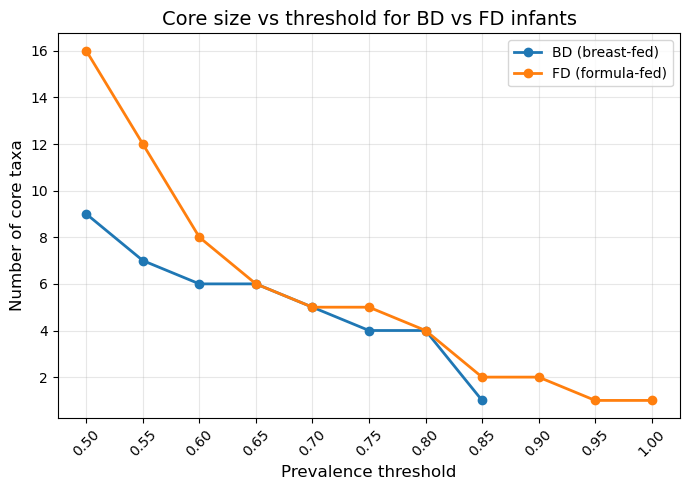

In [18]:
plt.figure(figsize=(7,5))

# Plot BD
plt.plot(bd_thr, bd_counts, marker="o", linewidth=2, label="BD (breast-fed)", color="#1f77b4")

# Plot FD
plt.plot(fd_thr, fd_counts, marker="o", linewidth=2, label="FD (formula-fed)", color="#ff7f0e")

plt.xlabel("Prevalence threshold", fontsize=12)
plt.ylabel("Number of core taxa", fontsize=12)
plt.title("Core size vs threshold for BD vs FD infants", fontsize=14)
plt.xticks(bd_thr + [t for t in fd_thr if t not in bd_thr], rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 3. Core Taxa Comparison Between Breast-Fed and Formula-Fed Infants

This section combines the BD and FD core-microbiota results to see which genera are shared and which are specific to one feeding group. The goal is to track how these patterns change as the prevalence threshold becomes stricter. To do this, genus names are extracted, a matrix is created to label each genus as shared, BD-only, FD-only, or not core, and the results are visualized in a heatmap.

This helper function extracts the genus name from the taxonomy strings in the exported tables. It ensures consistent labeling before combining BD and FD results.

In [19]:
# Helper: extract genus from taxonomy string
def extract_genus(taxon_str):
    if "g__" not in taxon_str:
        return "Unassigned"
    return taxon_str.split("g__")[-1].strip()

Only thresholds that appear in both BD and FD are used for comparison. A lower cutoff (≥0.60) is chosen so genera are not lost too quickly. Genera that appear in either group at the cutoff level are included in the comparison.

In [20]:
# Determine thresholds present in both groups
common_thresholds = sorted(set(bd_core_data.keys()) & set(fd_core_data.keys()))
show_thresholds = [t for t in common_thresholds if t >= 0.60]
thr_labels = [f"{t:.2f}" for t in show_thresholds]

# Find genera that are core in either BD or FD at a chosen cutoff
cutoff = 0.65
bd_taxa_cut = set(bd_core_data[cutoff]["Feature ID"])
fd_taxa_cut = set(fd_core_data[cutoff]["Feature ID"])

important_taxa = sorted(bd_taxa_cut | fd_taxa_cut)
important_genera = sorted(extract_genus(t) for t in important_taxa)

A matrix is created where each genus is labeled at every threshold as BD-only, FD-only, shared, or not core. This forms the basis of the final comparison heatmap.

In [21]:
# Build matrix with values: 0=none, 1=BD-only, 2=FD-only, 3=shared
status_df = pd.DataFrame(0, index=important_genera, columns=thr_labels)

for thr, thr_label in zip(show_thresholds, thr_labels):
    bd_gen = {extract_genus(t) for t in bd_core_data[thr]["Feature ID"]}
    fd_gen = {extract_genus(t) for t in fd_core_data[thr]["Feature ID"]}
    
    for g in important_genera:
        if g in bd_gen and g in fd_gen:
            status_df.loc[g, thr_label] = 3
        elif g in bd_gen:
            status_df.loc[g, thr_label] = 1
        elif g in fd_gen:
            status_df.loc[g, thr_label] = 2


Genera are automatically ordered based on their core-pattern vector so that shared, BD-only, and FD-only genera group together without manual sorting.

In [22]:
# Sort genera automatically by pattern vector
status_df["sort_key"] = status_df.values.tolist()
status_df = status_df.sort_values("sort_key", ascending=False)
status_df = status_df.drop(columns=["sort_key"])

A discrete colormap is defined for the four categories in the matrix.

In [23]:
cmap = ListedColormap([
    "#f0f0f0",  # not core
    "#377eb8",  # BD-only
    "#ff7f00",  # FD-only
    "#4daf4a"   # shared
])
norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], cmap.N)

Plot the heatmap

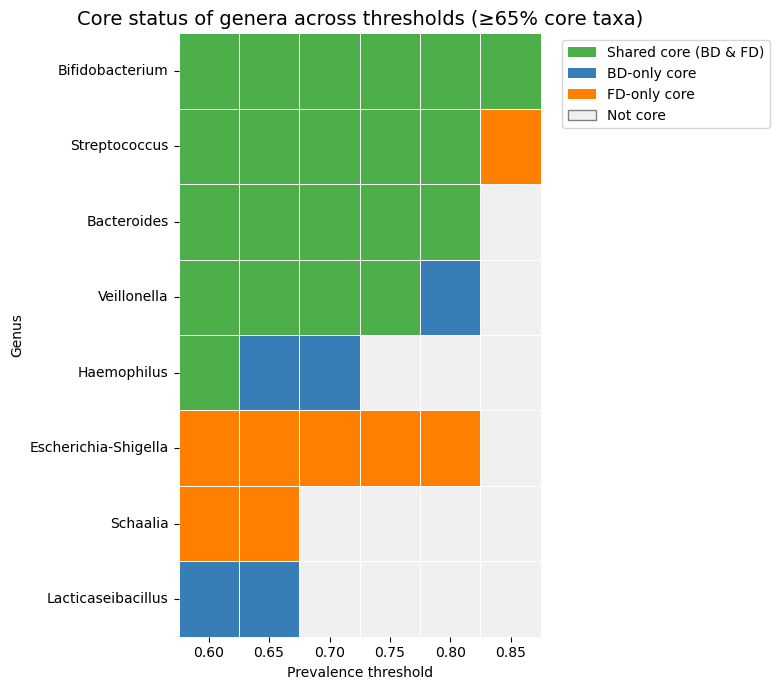

In [24]:
plt.figure(figsize=(8, 3 + 0.5*len(important_genera)))

sns.heatmap(
    status_df,
    cmap=cmap,
    norm=norm,
    cbar=False,
    linewidths=.5,
    linecolor="white"
)

plt.title("Core status of genera across thresholds (≥65% core taxa)", fontsize=14)
plt.xlabel("Prevalence threshold")
plt.ylabel("Genus")

handles = [
    Patch(facecolor="#4daf4a", label="Shared core (BD & FD)"),
    Patch(facecolor="#377eb8", label="BD-only core"),
    Patch(facecolor="#ff7f00", label="FD-only core"),
    Patch(facecolor="#f0f0f0", edgecolor="gray", label="Not core"),
]
plt.legend(handles=handles, bbox_to_anchor=(1.04, 1), loc="upper left")

plt.tight_layout()
plt.show()



The heatmap shows that *Bifidobacterium* is a stable core genus in both breast-fed (BD) and formula-fed (FD) infants. This suggests that it plays a key role in early gut development, regardless of diet. Previous studies report that *Bifidobacterium* commonly dominates the infant gut, which supports this finding.

Veillonella appears as a core genus in both groups at lower thresholds, but at stricter thresholds it remains core mainly in breast-fed infants. This may be explained by the way breast milk shapes the gut environment. Breast milk promotes strong fermentation by *Bifidobacterium*, which produces lactate. Veillonella can use this lactate, so it may benefit more in infants who receive breast milk. The pattern seen in the heatmap fits this type of cooperative relationship.

In contrast, *Escherichia-Shigella* is consistently part of the core only in formula-fed infants. This suggests that formula feeding creates conditions that support facultative anaerobes. These bacteria are often able to tolerate more oxygen and may thrive when the gut is not as strongly dominated by milk-fermenting species. Many studies have reported higher levels of Enterobacteriaceae in formula-fed infants, which matches the pattern observed here.

Streptococcus and Bacteroides remain shared between the groups across most thresholds. This suggests that some early colonizers are common to all infants and are less influenced by diet. Other genera, such as Haemophilus and Lacticaiseibacillus, appear only at lower thresholds, which suggests that they are not stable enough to be considered core across many infants.

Taken together, these results show that there is a small shared core microbiota in all infants, but diet influences which additional genera become consistently present. Breast-fed infants tend to show a fermentation-based community shaped by milk, while formula-fed infants show higher stability of facultative anaerobes. These differences suggest that feeding mode influences not only which bacteria appear, but also how reliably they colonize the gut.


# References

https://bioinformatics.ccr.cancer.gov/docs/qiime2/Lesson7/


<div style="border: 2px solid red; padding: 10px; color: red; font-weight: bold;">
 Note: References need to be updated
</div>